# 05 Microenvironment Evolution

This notebook investigates the evolution of solution pH during SBF immersion and its implications for transport behavior, interfacial chemistry, and bioactivity.

The Kinetic Blueprint framework proposes that thermal processing influences microenvironment evolution through changes in phase architecture, network connectivity, and transport behavior.

## Research Question

How does thermal processing regulate pH evolution and microenvironmental conditions during degradation of spray-pyrolyzed apatite–wollastonite glass-ceramics?

## Scientific Motivation

Previous analyses demonstrated that:

- Higher NBO/BO ratios increase mass loss.
- Higher NBO/BO ratios increase calcium release.
- Higher NBO/BO ratios increase silicon release.
- Higher density suppresses transport behavior.

However, transport behavior ultimately modifies the local chemical environment.

Solution pH provides a direct measure of microenvironment evolution and serves as a bridge between transport behavior and biological response.

This notebook explores how thermal processing influences alkalization dynamics during SBF immersion.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT_DIR = Path("..")
DATA_DIR = ROOT_DIR / "data"

pH_df = pd.read_csv(DATA_DIR / "pH_time_series.csv")

pH_df.head()

,Time_Days,Temperature_C,pH_Value,Interfacial_Classification
0,0,700,7.40,Baseline SBF
1,1,700,8.32,Alkaline Shock
2,3,700,8.55,Peak Alkaline Shock
3,5,700,8.48,Cytotoxic Region
4,7,700,8.42,Cytotoxic Region


## pH Evolution During SBF Immersion

The following analysis compares pH evolution across all processing conditions.

A rapid increase in pH indicates accelerated ion exchange and network dissolution, whereas stable pH behavior suggests controlled transport and buffered interfacial chemistry.

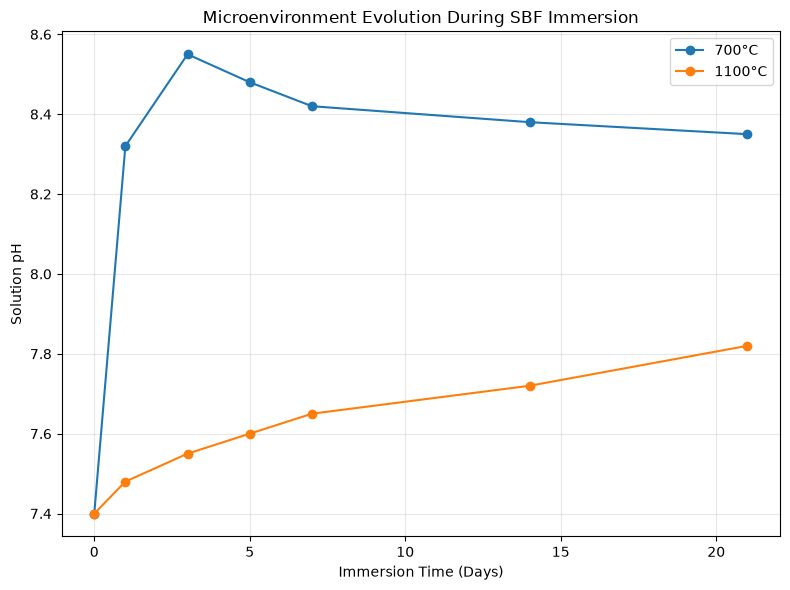

In [2]:
plt.figure(figsize=(8,6))

for temp in sorted(pH_df["Temperature_C"].unique()):
    
    subset = pH_df[pH_df["Temperature_C"] == temp]
    
    plt.plot(
        subset["Time_Days"],
        subset["pH_Value"],
        marker="o",
        label=f"{temp}°C"
    )

plt.xlabel("Immersion Time (Days)")
plt.ylabel("Solution pH")
plt.title("Microenvironment Evolution During SBF Immersion")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Network Connectivity and Microenvironment Evolution

### Scientific Motivation

Previous analyses demonstrated that network connectivity governs degradation behavior and ionic transport.

If transport behavior drives microenvironment evolution, then the NBO/BO ratio should also influence the final solution pH after SBF immersion.

The following analysis evaluates whether network depolymerization promotes alkalization of the surrounding environment.

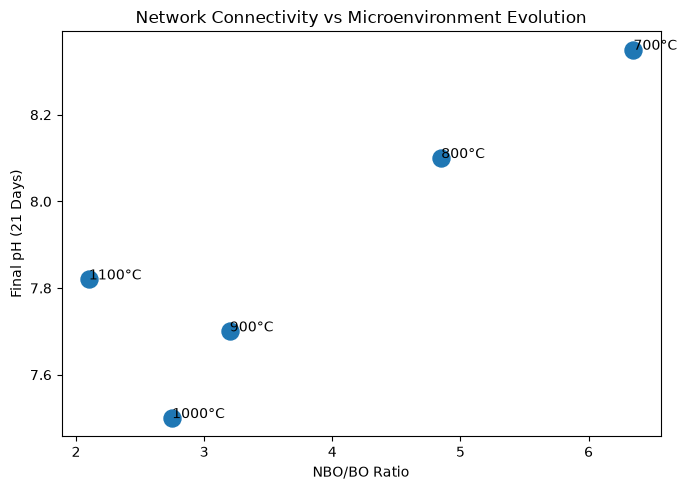

In [3]:
kb_df = pd.read_csv(DATA_DIR / "kinetic_blueprint_master.csv")

plt.figure(figsize=(7,5))

plt.scatter(
    kb_df["NBO_BO_Ratio"],
    kb_df["Final_pH_21d"],
    s=150
)

for _, row in kb_df.iterrows():
    plt.annotate(
        f"{int(row['Temperature_C'])}°C",
        (row["NBO_BO_Ratio"], row["Final_pH_21d"])
    )

plt.xlabel("NBO/BO Ratio")
plt.ylabel("Final pH (21 Days)")
plt.title("Network Connectivity vs Microenvironment Evolution")

plt.tight_layout()
plt.show()

## Interpretation

A positive relationship is expected between NBO/BO ratio and final solution pH.

Materials with higher NBO/BO ratios exhibit more depolymerized networks, facilitating ion exchange and transport processes that elevate solution alkalinity.

This observation extends the Kinetic Blueprint framework by linking network connectivity not only to transport behavior but also to microenvironment regulation.

The results suggest that thermal processing can indirectly program local chemical conditions through control of network architecture.

## Transport Behavior and Microenvironment Evolution

### Scientific Motivation

Previous analyses demonstrated that network connectivity influences degradation behavior.

If degradation drives alkalization of the surrounding environment, then materials exhibiting greater mass loss should also produce higher final pH values.

The following analysis evaluates the relationship between transport activity and microenvironment evolution.

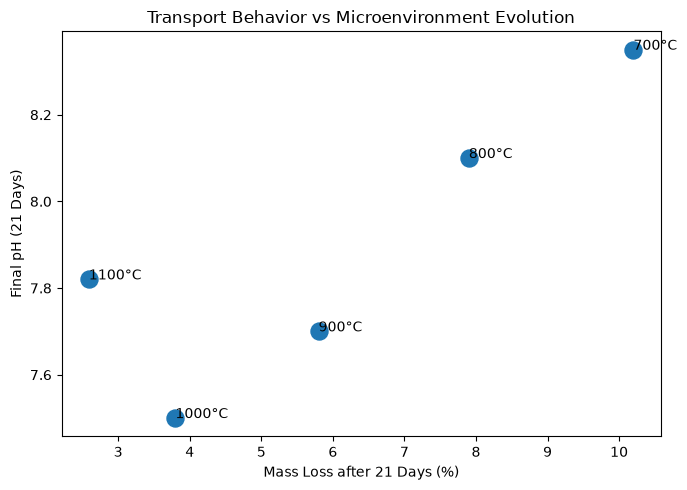

In [4]:
plt.figure(figsize=(7,5))

plt.scatter(
    kb_df["MassLoss_21d_Percent"],
    kb_df["Final_pH_21d"],
    s=150
)

for _, row in kb_df.iterrows():
    plt.annotate(
        f"{int(row['Temperature_C'])}°C",
        (row["MassLoss_21d_Percent"], row["Final_pH_21d"])
    )

plt.xlabel("Mass Loss after 21 Days (%)")
plt.ylabel("Final pH (21 Days)")
plt.title("Transport Behavior vs Microenvironment Evolution")

plt.tight_layout()
plt.show()

## Interpretation

A positive relationship is expected between mass loss and final solution pH.

Materials exhibiting greater degradation release larger quantities of ionic species into the surrounding medium, increasing alkalinity and modifying the local chemical environment.

This relationship provides direct evidence that transport behavior mediates microenvironment evolution.

Together with the NBO/BO analysis, these results support the Kinetic Blueprint pathway:

Network Connectivity
↓
Transport Behavior
↓
Microenvironment Evolution
↓
Bioactivity

## Ionic Transport and Microenvironment Evolution

### Scientific Motivation

Calcium release represents one of the primary transport processes occurring during degradation of bioactive glass-ceramics.

If ionic transport contributes to microenvironment regulation, then materials exhibiting greater calcium release should also produce greater alkalization of the surrounding solution.

The following analysis evaluates the relationship between calcium transport and final pH after 21 days of SBF immersion.

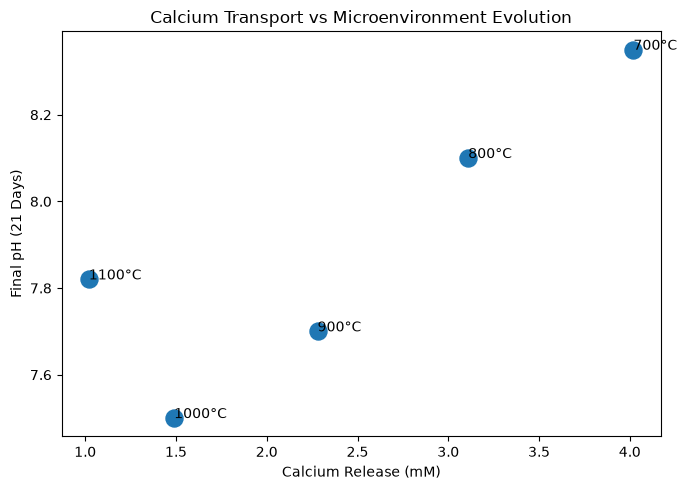

In [5]:
plt.figure(figsize=(7,5))

plt.scatter(
    kb_df["Ca_Release_21d_mM"],
    kb_df["Final_pH_21d"],
    s=150
)

for _, row in kb_df.iterrows():
    plt.annotate(
        f"{int(row['Temperature_C'])}°C",
        (row["Ca_Release_21d_mM"], row["Final_pH_21d"])
    )

plt.xlabel("Calcium Release (mM)")
plt.ylabel("Final pH (21 Days)")
plt.title("Calcium Transport vs Microenvironment Evolution")

plt.tight_layout()
plt.show()

## Interpretation

A positive relationship is expected between calcium release and final solution pH.

Materials exhibiting greater calcium transport produce stronger modification of the surrounding chemical environment.

This observation suggests that ionic transport contributes directly to microenvironment evolution and may influence subsequent biological responses.

Together with the mass-loss analysis, these results support the hypothesis that transport behavior governs microenvironment regulation within the Kinetic Blueprint framework.

## Network Dissolution and Microenvironment Evolution

### Scientific Motivation

Silicon release reflects dissolution of the silicate framework and therefore provides a direct measure of network breakdown.

If network dissolution contributes to microenvironment regulation, then materials exhibiting greater silicon release should also produce stronger alkalization of the surrounding solution.

The following analysis evaluates the relationship between silicon transport and final pH after 21 days of SBF immersion.

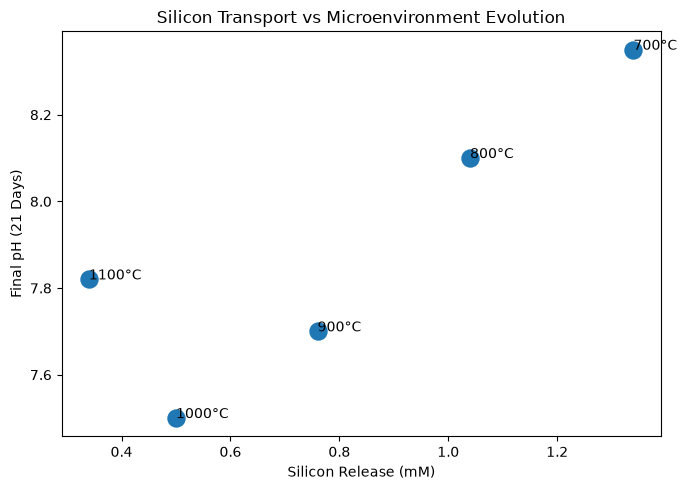

In [6]:
plt.figure(figsize=(7,5))

plt.scatter(
    kb_df["Si_Release_21d_mM"],
    kb_df["Final_pH_21d"],
    s=150
)

for _, row in kb_df.iterrows():
    plt.annotate(
        f"{int(row['Temperature_C'])}°C",
        (row["Si_Release_21d_mM"], row["Final_pH_21d"])
    )

plt.xlabel("Silicon Release (mM)")
plt.ylabel("Final pH (21 Days)")
plt.title("Silicon Transport vs Microenvironment Evolution")

plt.tight_layout()
plt.show()

## Interpretation

A positive relationship is expected between silicon release and final solution pH.

Materials exhibiting greater silicate-network dissolution generate stronger modifications of the surrounding chemical environment.

This observation suggests that microenvironment evolution is influenced not only by degradation and modifier-ion release but also by dissolution of the glass framework itself.

Together with the calcium-release analysis, these results support the hypothesis that transport-mediated microenvironment regulation emerges from network architecture and dissolution behavior.

## Initial Interpretation

Distinct microenvironment trajectories emerge across the processing window.

### Reactive Transport Domain (700–800 °C)

These samples exhibit rapid alkalization, indicating strong transport activity and extensive ion exchange.

### Balanced Transport Domain (900–1000 °C)

These samples maintain relatively stable pH values and demonstrate controlled transport behavior.

### Condensed Diffusion Domain (1100 °C)

These samples exhibit delayed and gradual alkalization, consistent with diffusion-governed transport and enhanced structural stability.

Together, these observations suggest that thermal processing governs not only transport behavior but also the evolution of the interfacial chemical environment.

## Microenvironment Evolution within the Kinetic Blueprint Framework

### Scientific Synthesis

The pH time-series dataset extends the Kinetic Blueprint framework beyond transport behavior and introduces microenvironment regulation as a measurable outcome of materials design.

The combined analyses support the following hierarchy:

Thermal Processing
↓
Phase Architecture
↓
Network Connectivity
↓
Transport Behavior
↓
Microenvironment Evolution
↓
Bioactivity Response

Key observations include:

- Higher NBO/BO ratios increase final pH.
- Greater mass loss increases final pH.
- Greater calcium release increases final pH.
- Greater silicon release increases final pH.

These relationships suggest that thermal processing can indirectly program local chemical conditions through control of phase architecture, network connectivity, and transport behavior.

Microenvironment evolution therefore represents an emergent property of processing-induced structural design.